# ✨ Que número é esse AI?

📌 **Mini‑projeto — Módulo 2 | Programa SCTEC**

**Bibliotecas do projeto**

In [16]:
# Bibliotecas padrão
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# Persistência de modelos
from pathlib import Path
import joblib
from joblib import load

# Scikit-learn: datasets, modelos e métricas
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Modelos de classificação
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

## Dataset MNIST (Modified National Institute of Standards and Technology)

O **MNIST** é o dataset "Hello World" da visão computacional, ideal para testar métodos de reconhecimento de padrões com um mínimo esforço de pré-processamento.

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

* Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.


In [2]:
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")


Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


* Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

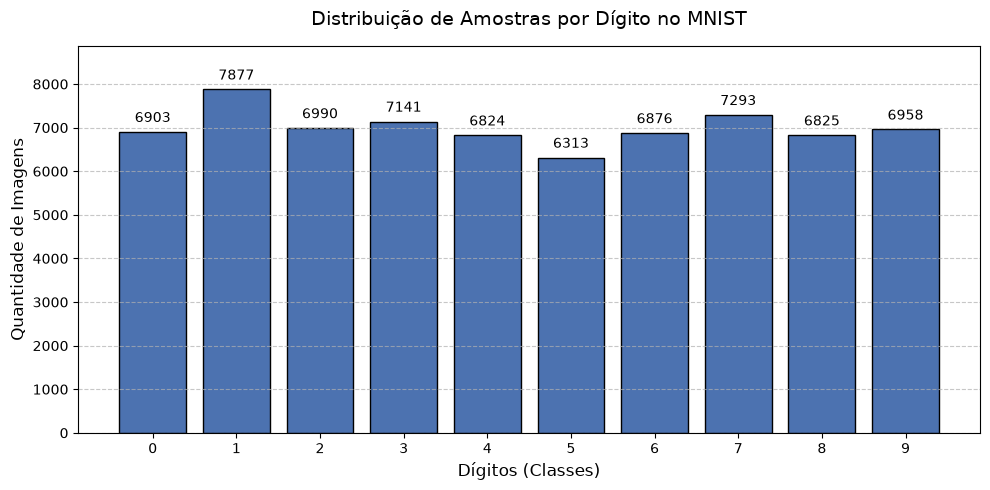

In [3]:
# Descrição completa do dataset
print(mnist.DESCR)
print("Chaves:", mnist.keys())

# Separando as matrizes de features (X) (as imagens) e rótulos/alvo (y) (os rótulos de 0 a 9)
X, y = mnist.data, mnist.target

print("-" * 40)
print("📊 ANÁLISE EXPLORATÓRIA DO MNIST 📊")
print("-" * 40)
print(f"Dimensão de X (Imagens): {X.shape} -> {X.shape[0]} amostras com {X.shape[1]} features cada")
n_pixels = int(np.sqrt(X.shape[1]))
print(f"Formato original de cada feature X: imagem de {n_pixels}x{n_pixels} = {X.shape[1]} pixels")
print(f"Dimensão de y (Rótulos): {y.shape} -> {y.shape[0]} respostas correspondentes")
print(f"Rótulos possíveis: {sorted(set(mnist.target))}")
print("-" * 40)

# -------------------------------------------------------------
# Balanceamento das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição de amostras por dígito:")
for c, count in zip(classes, contagens):
    print(f"Dígito {c}: {count} imagens")

# Vamos fazer um histograma da distribuição
plt.figure(figsize=(10, 5))
barras = plt.bar(classes, contagens, color='#4C72B0', edgecolor='black')

plt.title("Distribuição de Amostras por Dígito no MNIST", fontsize=14, pad=15)
plt.xlabel("Dígitos (Classes)", fontsize=12)
plt.ylabel("Quantidade de Imagens", fontsize=12)
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 150,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(contagens) + 1000)

plt.tight_layout()
plt.show()


* Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.


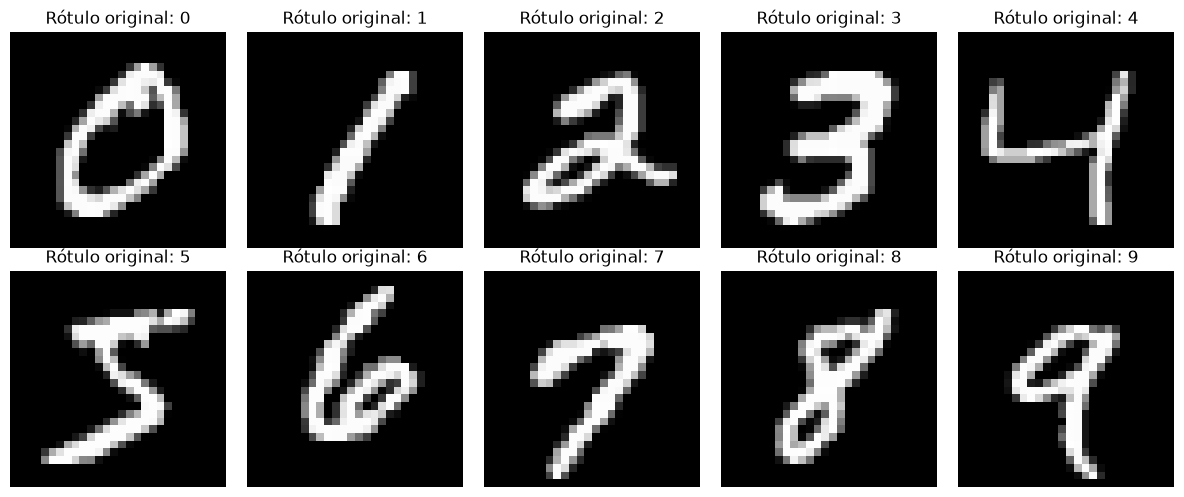

In [4]:
# Extraindo algumas imagens

# Criamos uma grade 2x5 para exibir um exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for i in range(10):
    # Garantimos uma imagem de cada número
    idx = np.where(y == str(i))[0][0]

    imagem_28x28 = X[idx].reshape(28, 28)

    axes[i].imshow(imagem_28x28, cmap='gray')
    axes[i].set_title(f"Rótulo original: {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

* Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).

**Estrutura e Origem**

* **Volume Total:** 70.000 imagens de dígitos manuscritos (0 a 9).

* **Autoria:** Criado a partir de bases do NIST americano, misturando amostras escritas por funcionários do censo (base mais limpa) e estudantes do ensino médio (base mais ruidosa).

**Características Técnicas**

* **Formato Original:** Matrizes de $28 \times 28$ pixels. Os dígitos foram normalizados em tamanho e centralizados calculando o "centro de massa" dos pixels.

* **Vetorização:** Para a maioria dos algoritmos, a matriz bidimensional é "achatada" num vetor $\vec{x}$ de **784 dimensões** (features).

* **Intensidade (Pixels):** Escala de cinza de **0** (fundo) a **255** (traço máximo). Os tons de cinza intermediários são resultado da técnica de *anti-aliasing* usada na redução da imagem original.

Então, temos o seguinte problema: cada imagem $i$ é um vetor $\vec{x}^{(i)} = (x_1^{(i)},..., x_{784}^{(i)})$, em que as componentes $x_{j}^{(i)}$ é um pixel com um valor entre $0$ e $255$. Queremos aprender a classificar esses vetores dentros dos rótulos de $0$ a $9$.

**Balanceamento de Classes**

O dataset apresenta uma distribuição muito equilibrada (sem forte viés para nenhum número específico). As amostras variam de forma suave entre o **dígito 5** (classe minoritária, com 6.313 imagens) e o **dígito 1** (classe majoritária, com 7.877 imagens), com a média girando em torno de 7.000 imagens por número.

### Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

* Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), garantindo estratificação por classe (stratify=y).


📊 DIVISÃO ESTRATIFICADA DOS DADOS 📊
--------------------------------------------------
Conjunto de Treino:    49000 amostras (70%)
Conjunto de Validação: 7000  amostras (10%)
Conjunto de Teste:     14000 amostras (20%)
--------------------------------------------------


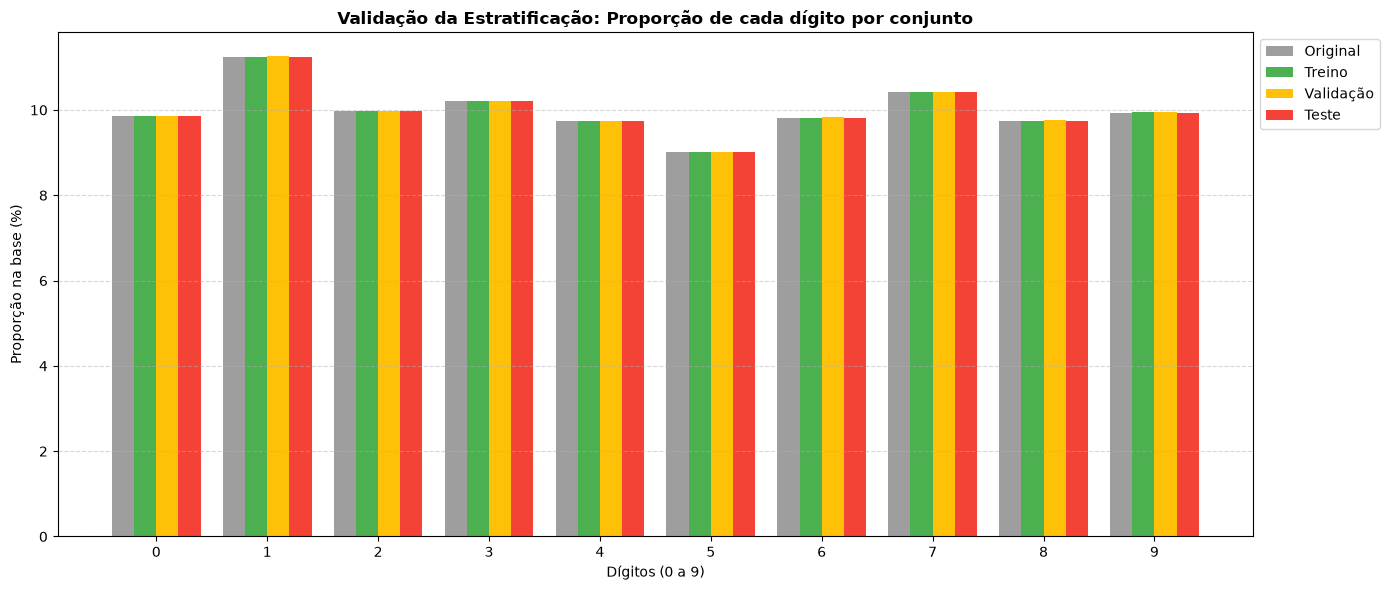

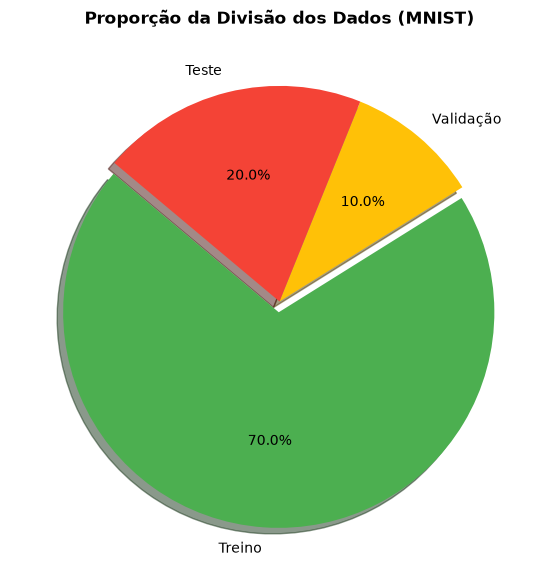

In [5]:
# Primeiro vamos separar Teste (20%) e o restante temporário para Treino/Validação (80%)
# Os dados de teste só serão acessados ao final, garantindo que o modelo não teve acesso durante o treino.
# Usamos o stratify para garantir a mesma proporção de classes. Do contrário, por exemplo, poderíamos ter muitos 8 e nenhum 2.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20, # proporção do split 20%
    stratify=y,     # mesma proporção de classes  
    random_state=42 # random padrão para a reprodutibilidade
)

# Separar Validação (10% do total) e Treino (70% do total) a partir do temp
# 12.5% de 80% = 10% do total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    stratify=y_temp,  # Mantemos a estratificação
    random_state=42
)

print("📊 DIVISÃO ESTRATIFICADA DOS DADOS 📊")
print("-" * 50)
print(f"Conjunto de Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de Validação: {X_val.shape[0]}  amostras ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print("-" * 50)

# ----------------------------------------------------
# Vamos comprovar a eficácia da estratificação (stratify=y)

def check_proportion(y_array):
    _, counts = np.unique(y_array, return_counts=True)
    return (counts / len(y_array)) * 100

# Extraindo as porcentagens para cada conjunto
prop_orig = check_proportion(y)
prop_train = check_proportion(y_train)
prop_val = check_proportion(y_val)
prop_test = check_proportion(y_test)

# Configurações do gráfico
digitos = np.arange(10)
largura = 0.2  # Largura individual de cada barra

plt.figure(figsize=(14, 6))

plt.bar(digitos - largura*1.5, prop_orig, width=largura, label='Original', color='#9E9E9E')
plt.bar(digitos - largura*0.5, prop_train, width=largura, label='Treino', color='#4CAF50')
plt.bar(digitos + largura*0.5, prop_val, width=largura, label='Validação', color='#FFC107')
plt.bar(digitos + largura*1.5, prop_test, width=largura, label='Teste', color='#F44336')

plt.title("Validação da Estratificação: Proporção de cada dígito por conjunto", fontweight='bold')
plt.xlabel("Dígitos (0 a 9)")
plt.ylabel("Proporção na base (%)")
plt.xticks(digitos) # Garante que o eixo X mostre exatamente de 0 a 9
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ----------------------------------------------------
#Vamos fazer um diagrama de pizza

tamanhos = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = ['Treino', 'Validação', 'Teste']
cores = ['#4CAF50', '#FFC107', '#F44336']
destaque = (0.05, 0, 0)  # Afasta levemente a primeira fatia (Treino) para destaque

plt.figure(figsize=(7, 7))
plt.pie(
    tamanhos, 
    labels=labels, 
    colors=cores, 
    autopct='%1.1f%%', 
    explode=destaque,
    startangle=140,
    shadow=True
)

plt.title("Proporção da Divisão dos Dados (MNIST)", fontweight='bold')
plt.show()

* Normalização / Escalonamento: Aplicar o redimensionamento dos pixels para a escala [0.0, 1.0] (dividindo por 255.0 ou via MinMaxScaler/StandardScaler).
  
* Justificar textualmente a importância da normalização para a convergência de modelos lineares e distâncias métricas.

In [6]:
X_train_norm = X_train / 255.0
X_val_norm = X_val / 255.0
X_test_norm = X_test / 255.0

print("📊 VERIFICAÇÃO DO ESCALONAMENTO 📊")
print("-" * 50)
print(f"Treino original:    min {np.min(X_train):.1f} | max {np.max(X_train):.1f}")
print(f"Treino normalizado: min {np.min(X_train_norm):.1f} | max {np.max(X_train_norm):.1f}")
print(f"Teste original:     min {np.min(X_test):.1f} | max {np.max(X_test):.1f}")
print(f"Teste normalizado:  min {np.min(X_test_norm):.1f} | max {np.max(X_test_norm):.1f}")
print("-" * 50)

📊 VERIFICAÇÃO DO ESCALONAMENTO 📊
--------------------------------------------------
Treino original:    min 0.0 | max 255.0
Treino normalizado: min 0.0 | max 1.0
Teste original:     min 0.0 | max 255.0
Teste normalizado:  min 0.0 | max 1.0
--------------------------------------------------


**A Importância Matemática da Normalização [0, 1]**

* **Convergência em Otimizações por Gradiente:** Algoritmos que otimizam pesos minimizando uma função de custo (como regressões logísticas ou redes neurais) dependem da geometria do espaço paramétrico. Quando as *features* possuem escalas muito amplas (0 a 255), as curvas de nível da função de perda tornam-se distorcidas e elípticas, forçando a descida do gradiente a oscilar em "zigue-zague" e atrasando a convergência. Ao redimensionar para [0, 1], a topologia do erro torna-se mais esférica, permitindo que as atualizações dos tensores apontem mais diretamente para o mínimo.
 
* **Estabilidade em Algoritmos Métricos:** Modelos que dependem de similaridade espacial (como KNN ou SVM) calculam rotineiramente a Distância Euclidiana ou de Manhattan. Sem o escalonamento, pixels com valores absolutos naturalmente mais altos dominariam o cálculo da distância hiperespacial de forma desproporcional. A normalização garante que cada dimensão do vetor (pixel) exerça peso equitativo na métrica.

### Fase 3: Implementação e Treinamento dos 3 Modelos

---

Vamos escolher 3 modelos de classificação para tentar prever o número correto presente na imagem. Devemos escolher um modelo de classificação pois cada número representa uma classe dentro do grupo das imagens, não sendo um target contínuo, mas sim, discreto. 

**Metodologia:**
- Para cada modelo vamos variar 2 hiperparâmetros para encontrar a melhor versão de cada modelo
- A escolha da melhor versão será feita avaliando 4 métricas calculadas com o df de validação e maximizando a acurácia do resultado

---

#### SVM (Support Vector Machine)

🔹 Hiperparâmetros que serão testados
- **`C`** (margem de separação):  o quanto estamos penalizando o erro na classificação dos pontos
    - Baixo (0.1): margem larga, mais tolerância a erros → pode subajustar.
    - Médio (1–10): equilíbrio entre generalização e ajuste.
    - Alto (100): margem estreita, menos tolerância → risco de overfitting.

- **`kernel`**: define a forma da fronteira de decisão (pode ser uma linha reta, um círculo, ...).
    - RBF (Radial Basis Function): padrão, captura fronteiras não lineares; exige ajuste de gamma.
    - Linear: rápido, bom para dados com muitas features e separação linear.

In [7]:

resultados_svm = []

# Inicialização métricas
acc_best = 0.0
best_model_svm = None
best_model_metrics_svm = None
    
for c in np.logspace(-1, 2, num=4, base=10):
    for kernel in ['rbf', 'linear']:
        print(f'C = {c}')
        print(f'kernel = {kernel}')

        modelo_svm = SVC(kernel=kernel, C=c, gamma='scale', decision_function_shape='ovr')
        modelo_svm.fit(X_train_norm, y_train)

        # Faz previsões
        y_pred = modelo_svm.predict(X_val_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro')
        rec = recall_score(y_val, y_pred, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')
        
        resultados_svm.append({
            "C": c,
            "Kernel": kernel,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        if (acc > acc_best):
            best_model_svm = modelo_svm
            acc_best = acc
            best_model_metrics_svm = {
                "C": c,
                "Kernel": kernel,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1
            }



C = 0.1
kernel = rbf
C = 0.1
kernel = linear
C = 1.0
kernel = rbf
C = 1.0
kernel = linear
C = 10.0
kernel = rbf
C = 10.0
kernel = linear
C = 100.0
kernel = rbf
C = 100.0
kernel = linear


In [8]:
# Exibir resultados em formato de tabela

df_resultados = pd.DataFrame(resultados_svm)
print(df_resultados)

       C  Kernel  Accuracy  Precision    Recall        F1
0    0.1     rbf  0.953714   0.953600  0.953468  0.953417
1    0.1  linear  0.943000   0.942713  0.942337  0.942433
2    1.0     rbf  0.975571   0.975607  0.975508  0.975543
3    1.0  linear  0.936714   0.936618  0.935872  0.936053
4   10.0     rbf  0.981429   0.981382  0.981328  0.981343
5   10.0  linear  0.927143   0.927169  0.926228  0.926424
6  100.0     rbf  0.981429   0.981355  0.981341  0.981337
7  100.0  linear  0.922143   0.922147  0.921165  0.921304


In [9]:
print(f'''O melhor modelo foi obtido com os hiperparâmetros C = {best_model_metrics_svm['C']} e kernel = {best_model_metrics_svm['Kernel']} \n
As métricas são: 
- Acurácia: {best_model_metrics_svm['Accuracy']}
- Precisão: {best_model_metrics_svm['Precision']}
- Recall: {best_model_metrics_svm['Recall']}
- F1: {best_model_metrics_svm['F1']}''')

O melhor modelo foi obtido com os hiperparâmetros C = 10.0 e kernel = rbf 

As métricas são: 
- Acurácia: 0.9814285714285714
- Precisão: 0.9813824571905956
- Recall: 0.9813278197708583
- F1: 0.981342592613685


Vamos salvar o modelo  para usá-lo na próxima fase aplicando-o no dataset de teste

In [17]:
# salvar
Path("models").mkdir(parents=True, exist_ok=True)
joblib.dump(best_model_svm, "models/best_model_svm.pkl")

['models/best_model_svm.pkl']

---

#### Random Forest 

🔹 Hiperparâmetros que serão testados
- **`n_estimators`** (número de árvores)
  - Valores testados `[50, 100, 200, 400]`.
  - Mais árvores reduzem variância, mas aumentam tempo de treino.

- **`max_depth`** (profundidade máxima das árvores)
  - Valores testados `[5, 10, 20]`.
  - Valores menores forçam generalização.

In [18]:
resultados_rf = []


# Inicialização métricas
acc_best = 0.0
best_model_rf = None
best_model_metrics_rf = None
    
for n_estimator in 50 * np.logspace(0, 3, num=4, base=2):
    for max_depth in 5 * np.logspace(0, 2, num=3, base=2):
        print(f'n_estimator = {n_estimator}')
        print(f'max_depth = {max_depth}')

        modelo_rf = RandomForestClassifier(n_estimators=int(n_estimator), max_depth= int(max_depth), random_state=42, n_jobs=-1 ) 
        modelo_rf.fit(X_train_norm, y_train)

        # Faz previsões
        y_pred = modelo_rf.predict(X_val_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro')
        rec = recall_score(y_val, y_pred, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')
        
        resultados_rf.append({
            "n_estimator": n_estimator,
            "max_depth": max_depth,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        if (acc > acc_best):
            best_model_rf = modelo_rf
            acc_best = acc
            best_model_metrics_rf = {
                "n_estimator": n_estimator,
                "max_depth": max_depth,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1
            }




n_estimator = 50.0
max_depth = 5.0
n_estimator = 50.0
max_depth = 10.0
n_estimator = 50.0
max_depth = 20.0
n_estimator = 100.0
max_depth = 5.0
n_estimator = 100.0
max_depth = 10.0
n_estimator = 100.0
max_depth = 20.0
n_estimator = 200.0
max_depth = 5.0
n_estimator = 200.0
max_depth = 10.0
n_estimator = 200.0
max_depth = 20.0
n_estimator = 400.0
max_depth = 5.0
n_estimator = 400.0
max_depth = 10.0
n_estimator = 400.0
max_depth = 20.0


In [19]:
# Exibir resultados em formato de tabela
df_resultados_rf = pd.DataFrame(resultados_rf)
print(df_resultados_rf)

    n_estimator  max_depth  Accuracy  Precision    Recall        F1
0          50.0        5.0  0.849429   0.854888  0.845287  0.845464
1          50.0       10.0  0.944571   0.944878  0.943957  0.944242
2          50.0       20.0  0.962429   0.962283  0.962084  0.962133
3         100.0        5.0  0.854429   0.860358  0.850431  0.850680
4         100.0       10.0  0.946429   0.946681  0.945881  0.946102
5         100.0       20.0  0.965143   0.965053  0.964827  0.964899
6         200.0        5.0  0.859429   0.865850  0.855462  0.855819
7         200.0       10.0  0.947000   0.947234  0.946496  0.946699
8         200.0       20.0  0.966714   0.966649  0.966468  0.966515
9         400.0        5.0  0.858857   0.865632  0.854987  0.855547
10        400.0       10.0  0.947000   0.947192  0.946453  0.946674
11        400.0       20.0  0.966286   0.966175  0.966031  0.966057


In [20]:
print(f'''O melhor modelo foi obtido com os hiperparâmetros n_estimator = {best_model_metrics_rf['n_estimator']} e max_depth = {best_model_metrics_rf['max_depth']} \n
As métricas são: 
- Acurácia: {best_model_metrics_rf['Accuracy']}
- Precisão: {best_model_metrics_rf['Precision']}
- Recall: {best_model_metrics_rf['Recall']}
- F1: {best_model_metrics_rf['F1']}''')

O melhor modelo foi obtido com os hiperparâmetros n_estimator = 200.0 e max_depth = 20.0 

As métricas são: 
- Acurácia: 0.9667142857142857
- Precisão: 0.966648757148436
- Recall: 0.9664682036285136
- F1: 0.9665145989591938


Vamos salvar o modelo  para usá-lo na próxima fase aplicando-o no dataset de teste

In [21]:
# salvar
joblib.dump(best_model_rf, "models/best_model_rf.pkl")

['models/best_model_rf.pkl']

---
#### Neural Network

🔹 Hiperparâmetros importantes
- **`hidden_layer_sizes`**  
  - Define o número de neurônios em cada camada oculta.  
  - Exemplo: `(100,)` → uma camada com 100 neurônios.  
  - `(100, 50)` → duas camadas, a primeira com 100 e a segunda com 50 neurônios.  
  - Testamos potências de 2 para ajudar o processamento da cpu `[(64, ), (128, ), (16,), (128, 64), (16, 128), (16, 64) ]`.

- **`activation`**  
  - Função de ativação das camadas ocultas.  
  - Opções: `"relu"` (mais comum),  `"tanh"`, `"logistic"`.  
  - Testamos: `"relu"` e `"tanh"`.


In [ ]:
resultados_nn = []

# Inicialização métricas
acc_best = 0.0
best_model_nn = None
best_model_metrics_nn = None

# É bom usar potencias de 2 pois são mais próximos do hardware
for layers in [(64, ), (128, ), (16,), (128, 64), (16, 128), (16, 64)]:
    for activation in ["relu", "tanh"]:
        print(f'layers = {layers}')
        print(f'activation = {activation}')

        modelo_nn = MLPClassifier(hidden_layer_sizes=layers, activation= activation ) 
        modelo_nn.fit(X_train_norm, y_train)

        

        # Faz previsões
        y_pred = modelo_nn.predict(X_val_norm)
        
        # Calcula métricas
        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='macro')
        rec = recall_score(y_val, y_pred, average='macro')
        f1 = f1_score(y_val, y_pred, average='macro')
        
        resultados_nn.append({
            "hidden_layer_sizes": layers,
            "activation": activation,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1
        })

        if (acc > acc_best):
            best_model_nn = modelo_nn
            acc_best = acc
            best_model_metrics_nn = {
                "hidden_layer_sizes": layers,
                "activation": activation,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1
            }
            

layers = (64,)
activation = relu
layers = (64,)
activation = tanh
layers = (128,)
activation = relu
layers = (128,)
activation = tanh
layers = (16,)
activation = relu


/home/joaovitor/GitHub/sctec-mini-projeto2/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


layers = (16,)
activation = tanh


/home/joaovitor/GitHub/sctec-mini-projeto2/venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


layers = (128, 64)
activation = relu
layers = (128, 64)
activation = tanh
layers = (16, 128)
activation = relu
layers = (16, 128)
activation = tanh
layers = (16, 64)
activation = relu
layers = (16, 64)
activation = tanh


In [23]:
# Exibir resultados em formato de tabela
df_resultados_nn = pd.DataFrame(resultados_nn)
print(df_resultados_nn)

   hidden_layer_sizes activation  Accuracy  Precision    Recall        F1
0               (64,)       relu  0.973857   0.973735  0.973719  0.973708
1               (64,)       tanh  0.971857   0.971626  0.971615  0.971600
2              (128,)       relu  0.977000   0.976956  0.976850  0.976889
3              (128,)       tanh  0.976714   0.976522  0.976636  0.976544
4               (16,)       relu  0.942429   0.942338  0.941607  0.941874
5               (16,)       tanh  0.935429   0.934868  0.934748  0.934737
6           (128, 64)       relu  0.977571   0.977528  0.977452  0.977479
7           (128, 64)       tanh  0.979286   0.979182  0.979240  0.979185
8           (16, 128)       relu  0.959857   0.959454  0.959575  0.959493
9           (16, 128)       tanh  0.948286   0.948182  0.947997  0.948011
10           (16, 64)       relu  0.958571   0.958380  0.958506  0.958402
11           (16, 64)       tanh  0.949857   0.949348  0.949213  0.949241


In [25]:
print(f'''O melhor modelo foi obtido com os hiperparâmetros hidden_layer_sizes = {best_model_metrics_nn['hidden_layer_sizes']} e activation = {best_model_metrics_nn['activation']} \n
As métricas são: 
- Acurácia: {best_model_metrics_nn['Accuracy']}
- Precisão: {best_model_metrics_nn['Precision']}
- Recall: {best_model_metrics_nn['Recall']}
- F1: {best_model_metrics_nn['F1']}''')

TypeError: 'NoneType' object is not subscriptable

Vamos salvar o modelo  para usá-lo na próxima fase aplicando-o no dataset de teste

In [ ]:
# salvar
joblib.dump(best_model_nn, "models/best_model_nn.pkl")

### Fase 4: Avaliação Comparativa de Desempenho 

Primeiramente vamos aplicar a melhor versão de cada modelo no dataset de teste

In [ ]:
best_model_svm = load("models/best_model_svm.pkl") 
best_model_rf = load("models/best_model_rf.pkl") 
best_model_nn = load("models/best_model_nn.pkl") 

In [ ]:
y_pred_test_svm = best_model_svm.predict(X_test_norm)
y_pred_test_rf  = best_model_rf.predict(X_test_norm)
y_pred_test_nn  = best_model_nn.predict(X_test_norm)

In [ ]:
# Vamos definir uma função para calcular a matriz de confusão

def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    # Cria o gráfico com seaborn
    plt.figure(figsize=(6,4))

    labels = [f"$\\bf{{{i}}}$" for i in range(10)]  # gera 0–9 em negrito
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)

    # adiciona um retângulo em volta do heatmap
    ax.add_patch(patches.Rectangle((0,0), cm.shape[0], cm.shape[1],
                                fill=False, edgecolor='black', lw=3))

    plt.title("Matriz de Confusão")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.show()

**SVM**

In [ ]:
plot_confusion_matrix(y_test, y_pred_test_svm)

In [ ]:
print(classification_report(y_test, y_pred_test_svm, digits=3))

**Random Forest**

In [ ]:
plot_confusion_matrix(y_test, y_pred_test_rf)

In [ ]:
print(classification_report(y_test, y_pred_test_rf, digits=3))

**Neural Network**

In [ ]:
plot_confusion_matrix(y_test, y_pred_test_nn)

In [ ]:
print(classification_report(y_test, y_pred_test_nn, digits=3))

In [ ]:
resultados = []

for nome, y_pred in [("SVM", y_pred_test_svm),
                     ("Random Forest", y_pred_test_rf),
                     ("NN", y_pred_test_nn)]:
    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1-Score": f1_score(y_test, y_pred, average="weighted")
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)


**Conclusão**

Em todos os modelos houve maior confusão entre os `dígitos 4 e 9`. A maioria previu 9 onde era 4. Em particular, para as redes neurais, essa confusão ocupa o segundo lugar, sendo o primeiro ocupado pela previsão de 4 onde era 9.


Analisando as métricas dos modelos, vemos que o modelo que `melhor performou foi o SVM`. Todas as métricas calculadas com ele foram melhores do que as calculadas com os outros modelos tanto com a base de validação quanto com a base de teste.

Contudo, analisando o custo operacional, o SVM demorou em média meia hora para rodar com cada setup de hiperparâmetros enquanto o random forest (que apresentou o segundo melhor resultado) demorou, em média, 6 segundos para treinar com cada setup. Em vista disso, o `random forest é o modelo com o melhor custo operacional`.

### Fase 5: Desafio

#### Fase 5.1: Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

Como sugerido, vamos retirar os dígitos 4 e 7 da base de treino e treinar novamante o modelo random forest (escolhido por ter o melhor custo operacional)

In [ ]:
# como y_train é um array numpy podemos criar uma máscara que filtra os valores que não forem 4 e 7
mask = ~np.isin(y_train, ['4', '7'])   

# aplica a máscara
y_train_filtrado = y_train[mask]
X_train_filtrado = X_train_norm[mask]

In [ ]:
print("Classes restantes:", np.unique(y_train_filtrado))
print("Novo tamanho:", y_train_filtrado.shape[0])

Vamos treinar novamente o modelo com as bases filtradas

In [ ]:
# Hiperparâmetros do melhor modelo encontrado anteriormente
n_estimator = 200
max_depth = 20
    
modelo_rf = RandomForestClassifier(n_estimators=int(n_estimator), max_depth= int(max_depth), random_state=42, n_jobs=-1 ) 
modelo_rf.fit(X_train_filtrado, y_train_filtrado)


#### Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD)

Vamos fazer a máscara do dataset de teste. Nesse caso vamos filtrar somente as linhas com dígitos 4 e 7 

In [ ]:
mask_test = np.isin(y_test, ['4', '7'])   

# aplica a máscara
y_test_filtrado = y_test[mask_test]
X_test_filtrado = X_test_norm[mask_test]

In [ ]:
print("Classes restantes:", np.unique(y_test_filtrado))
print("Novo tamanho:", y_test_filtrado.shape[0])

Vamos aplicar o modelo treinado nessa base de teste

In [ ]:
y_pred_filtrado = modelo_rf.predict(X_test_filtrado)

**Análise dos resultados**

Métricas

In [ ]:
acc = accuracy_score(y_test_filtrado, y_pred_filtrado)
prec = precision_score(y_test_filtrado, y_pred_filtrado, average='macro')
rec = recall_score(y_test_filtrado, y_pred_filtrado, average='macro')
f1 = f1_score(y_test_filtrado, y_pred_filtrado, average='macro')

In [ ]:
print(f'''As métricas são: 
- Acurácia: {acc}
- Precisão: {prec}
- Recall: {rec}
- F1: {f1}''')

Como esperado, todas as métricas ficaram zeradas pois as classes do grupo de predição são totalmente diferentes das classes do conjunto de treino, logo não existem verdadeiros negativos nem verdadeiros positivos. Como esses valores ficam no numerador das métricas, todas ficam zeradas.

Para descobrir como o modelo classificou os números 4 e 7 (distribuição entre as classes presentes no treino), vamos calcular a matriz de confusão

In [ ]:
cm = confusion_matrix(y_test_filtrado, y_pred_filtrado)

O quinto elemento da lista de listas corresponde a distribuição da predição do dígito 4

In [ ]:
cm[4]

Enquanto, o oitavo elemento corresponde a distribuição do dígito 7

In [ ]:
cm[7]

Vamos plotar os histogramas dessas distribuições

In [ ]:
classes_todas = range(0,9)

# Vamos fazer um histograma da distribuição
plt.figure(figsize=(10, 5))
barras = plt.bar(classes, cm[4], color='#4C72B0', edgecolor='black')

plt.title("Distribuição das predições do dígito 4", fontsize=14, pad=15)
plt.xlabel("Dígitos (Classes)", fontsize=12)
plt.ylabel("Quantidade de predições", fontsize=12)
plt.xticks(classes_todas)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 10,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(cm[4]) + 100)

plt.tight_layout()
plt.show()


In [ ]:
classes_todas = range(0,9)

# Vamos fazer um histograma da distribuição
plt.figure(figsize=(10, 5))
barras = plt.bar(classes, cm[7], color='#4C72B0', edgecolor='black')

plt.title("Distribuição das predições do dígito 7", fontsize=14, pad=15)
plt.xlabel("Dígitos (Classes)", fontsize=12)
plt.ylabel("Quantidade de predições", fontsize=12)
plt.xticks(classes_todas)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 10,
             f'{int(altura)}',
             ha='center', va='bottom', fontsize=10)

plt.ylim(0, max(cm[7]) + 100)

plt.tight_layout()
plt.show()

**PERGUNTAS**

**Como o classificador reage ao ser forçado a classificar algo que nunca viu?**
O classificador classifica os dados do dataset de teste nas classes disponíveis na base de treino, ou seja, ele atribui aos números 4 e 7 valores que não são 4 e 7.

**Quais classes conhecidas ele atribui a esses dígitos desconhecidos?**
Pelos histogramas vemos que o classificador identifica tanto o dígito 4 quanto o 7 como sendo, majoritariamente, o dígito 9. Secundariamente, o dígito 4 é identificado como 8 e o dígito 7 como 2.

**Plot matriz de confusão**

In [ ]:
plot_confusion_matrix(y_test_filtrado, y_pred_filtrado)

**Conclusão**

A matriz de confusão mostra que o classificador continua tentando atribuir rótulos às amostras dessas classes (contidas na base de teste), mas como elas não existem mais no treino, ele força a classificação para outras classes conhecidas.  

Isso coincide com o conceito de **“Falsa Certeza”** (Overconfidence) que ocorre quando o modelo atribui uma **probabilidade muito alta** a uma previsão incorreta.  Por exemplo, no teste, o classificador pode prever “9” com 99% de confiança para uma imagem que na verdade é um “4”,  transmitindo ao usuário uma sensação enganosa de segurança. Esse problema pode ser grave quando presente em áreas da saúde, finanças, segurança, etc; pois pode levar a decisões erradas sem alerta de incerteza.  



#### Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias

Vamos tentar prever o número presente em uma imagem

**Carregar imagem e transformar em escala de cinza**

In [ ]:
# lê imagem já em escala de cinza
img = cv2.imread("imagens/numero2.png", cv2.IMREAD_GRAYSCALE)

**Redimensiona imagem**

In [ ]:
def redimencionaliza_figura(img):
    # blur leve
    img_blur = cv2.GaussianBlur(img, (3,3), 0)

    # threshold invertido (já inverte as cores das imagens - fundo branco se torna preto e traço preto se torna branco)
    _, img_bin = cv2.threshold(img_blur, 128, 255, cv2.THRESH_BINARY_INV)

    coords = cv2.findNonZero(img_bin)
    x, y, w, h = cv2.boundingRect(coords)

    # padding
    pad = 4
    cropped = img_bin[max(y-pad,0):y+h+pad, max(x-pad,0):x+w+pad]

    # resize suave
    resized = cv2.resize(cropped, (20, 20), interpolation=cv2.INTER_AREA)

    # canvas preto
    canvas = np.zeros((28,28), dtype=np.uint8)
    x_offset = (28 - resized.shape[1]) // 2
    y_offset = (28 - resized.shape[0]) // 2
    canvas[y_offset:y_offset+resized.shape[0], x_offset:x_offset+resized.shape[1]] = resized

    return canvas

In [ ]:
img_cropped = redimencionaliza_figura(img)
plt.imshow(img_cropped, cmap='gray')

**Normaliza imagem**

In [ ]:
img_norm = img_cropped / 255.0

In [ ]:
plt.imshow(img_norm, cmap='gray')

**Achata a imagem em um vetor com 784 entradas**

In [ ]:

img_flat = img_norm.flatten().reshape(1, -1)

**Aplica modelo**

In [ ]:
best_model_rf = load("models/best_model_rf.pkl") 

In [ ]:
y_pred  = best_model_rf.predict(img_flat)

In [ ]:
print("Classe prevista:", y_pred[0])

**Gráfico com a probabilidade**

In [ ]:
y_pred_proba  = best_model_rf.predict_proba(img_flat)

In [ ]:
# Plotar imagem processada + gráfico de probabilidades
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Imagem processada
axs[0].imshow(img_norm, cmap="gray")
axs[0].set_title(f"Imagem processada\nClasse prevista: {y_pred}")
axs[0].axis("off")

# Gráfico de probabilidades
axs[1].bar(range(10), y_pred_proba.flatten())
axs[1].set_xticks(range(10))
axs[1].set_xlabel("Classes")
axs[1].set_ylabel("Probabilidade")
axs[1].set_title("Distribuição das probabilidades")

plt.show()

**Nota:**

Vemos que o modelo obteve sucesso na classificação do número 2. Então agora vamos definir uma função para guardar todas as etapas da pipeline e aplicar a todas as imagens.

In [ ]:
def aplica_modelo_imagem(nome_imagem):
    # classifica imagem
    image = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)
    image_cropped = redimencionaliza_figura(image)
    image_norm = image_cropped/255.
    image_flat = image_norm.flatten().reshape(1, -1)
    y_pred  = best_model_rf.predict(image_flat)

    print("Classe prevista:", y_pred[0])

    # Analisa distribuição
    y_pred_proba  = best_model_rf.predict_proba(image_flat)
    # Plotar imagem processada + gráfico de probabilidades
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))

    # Imagem processada
    axs[0].imshow(image_norm, cmap="gray")
    axs[0].set_title(f"Imagem processada\nClasse prevista: {y_pred}")
    axs[0].axis("off")

    # Gráfico de probabilidades
    axs[1].bar(range(10), y_pred_proba.flatten())
    axs[1].set_xticks(range(10))
    axs[1].set_xlabel("Classes")
    axs[1].set_ylabel("Probabilidade")
    axs[1].set_title("Distribuição das probabilidades")

    plt.show()

**Lê todos os arquivos da pasta imagens**

In [ ]:
# Caminho da pasta
pasta = "imagens/*.png"   # pode ser .jpg, .jpeg etc.

# Lista todos os arquivos
arquivos = glob.glob(pasta)

**Aplica pipeline em todos os arquivos**

In [ ]:
for arquivo in arquivos:
    aplica_modelo_imagem(arquivo)

**Conclusão**

Vemos que dos 10 dígitos o modelo conseguiu prever corretamente a classe de 8 deles (o que significa uma acurácia de 80%). Durante a aplicação do modelo nas imagens, percebemos que havia números mais difíceis de serem identificados de forma correta. Isso pode acontecer tanto devido à diferença nos números de pixels entre as imagens recolhidas por nós e as contidas na base mnist quanto devido à localização da imagem. Após alguns testes percebemos que os números 0, 1 e 2 eram mais fáceis de serem reconhecidos do que os outros. Verificamos também que o restante dos números era melhor identificado quando as linhas dos números eram mais grossas. Mesmo testando vários formatos de números, vimos uma dificuldade em prever corretamente os números 7 e 9 (que ficaram errados em todos os testes que fizemos). Isso evidencia que a base mnist deveria ser treinada com mais amostras desses números (percebemos que a base contém números de tamanhos e posições muito parecidas) ou que os desenhos que fizemos dos dígitos não ficaram parecidos com os contidos na base.